In [6]:
import pandas as pd

In [7]:
merged_df = pd.read_csv("data/merged_df.csv")

## Case Study: Quadranten via Median im Startjahr

**Ziel**
Die vier Quadranten (low/high GHG, low/high Vulnerability) sollen die *globale Ausgangslage* im Startjahr repraesentieren.

**Definition (Schwellenwerte)**
- $ghg\_cut = \mathrm{median}(\mathrm{GHG\_per\_capita}\ |\ Year = Year_{start})$
- $vuln\_cut = \mathrm{median}(\mathrm{Vulnerability}\ |\ Year = Year_{start})$

**Vorteil**
Quadranten sind global interpretierbar ("Wo stand die Welt am Anfang?"), nicht auf die 4 Case-Laender zugeschnitten.


In [8]:

def build_case_study_df(
    merged_df: pd.DataFrame,
    iso3_list: list[str],
    x_col: str = "GHG_per_capita",
    y_col: str = "Vulnerability",
    year_col: str = "Year",
    id_col: str = "ISO3",
    country_col: str = "Country",
) -> pd.DataFrame:
    df = (
        merged_df.loc[
            merged_df[id_col].isin(iso3_list),
            [id_col, country_col, year_col, x_col, y_col],
        ]
        .dropna(subset=[x_col, y_col, year_col])
        .sort_values([id_col, year_col])
        .reset_index(drop=True)
    )

    df["is_start"] = df[year_col] == df.groupby(id_col)[year_col].transform("min")
    df["is_end"] = df[year_col] == df.groupby(id_col)[year_col].transform("max")
    return df


def quadrant_thresholds_from_start_year(
    merged_df: pd.DataFrame,
    start_year: int,
    x_col: str = "GHG_per_capita",
    y_col: str = "Vulnerability",
    year_col: str = "Year",
) -> tuple[float, float]:
    base = merged_df.loc[merged_df[year_col] == start_year, [x_col, y_col]].dropna()
    ghg_cut = float(base[x_col].median())
    vuln_cut = float(base[y_col].median())
    return ghg_cut, vuln_cut


In [10]:
# 1) deine 4 Laender:
iso3_case = ["PRT", "VUT", "BWA", "SOM"]

# 2) Startjahr automatisch aus merged_df nehmen (oder fix setzen)
start_year = int(merged_df["Year"].min())

# 3) Case-DF und Quadranten-Schwellen
case_df = build_case_study_df(merged_df, iso3_case)
ghg_cut, vuln_cut = quadrant_thresholds_from_start_year(merged_df, start_year)

case_df.head(), (start_year, ghg_cut, vuln_cut)


(  ISO3   Country  Year  GHG_per_capita  Vulnerability  is_start  is_end
 0  BWA  Botswana  1995        6.017021       0.497832      True   False
 1  BWA  Botswana  1996        5.340055       0.496986     False   False
 2  BWA  Botswana  1997        5.371740       0.493524     False   False
 3  BWA  Botswana  1998        5.776528       0.489069     False   False
 4  BWA  Botswana  1999        6.085979       0.485134     False   False,
 (1995, 3.8206017780000003, 0.4441034486099775))

## Case-Study-Visualisierung: GHG per capita vs. Vulnerability

**Ziel**
Diese Grafik zeigt die langfristigen Entwicklungspfade ausgewählter Länder im
zweidimensionalen Raum von Treibhausgasemissionen pro Kopf (GHG per capita)
und klimabezogener Verwundbarkeit (ND-GAIN Vulnerability).

Im Fokus stehen Länder, die über den Beobachtungszeitraum hinweg
gleichzeitig Emissionen pro Kopf **und** Vulnerability reduzieren konnten.

---

### Datengrundlage
Verwendet wird ein Länder-Paneldatensatz (`merged_df`) mit den Variablen:
- ISO3 (Ländercode)
- Country (Ländername)
- Year (Jahr)
- GHG_per_capita
- Vulnerability (ND-GAIN Vulnerability)

Für die Case Study wird ein dedizierter Teil-Datensatz (`case_df`)
aus `merged_df` gefiltert, der nur die ausgewählten Länder enthält.

---

### Quadranten-Definition
Das Koordinatensystem wird in vier Quadranten unterteilt durch:
- den **globalen Median von GHG per capita**
- den **globalen Median von Vulnerability**

Die Schwellenwerte werden **über alle Länder und alle Jahre**
des Datensatzes berechnet.
Dadurch entsteht eine zeitlich stabile Referenz, die Länderentwicklungen
vergleichbar macht.

---

### Darstellung der Länderentwicklung
Für jedes ausgewählte Land wird:
- die jährliche Entwicklung als **Trajektorie (Linie)** dargestellt
- der **Startpunkt** der Zeitreihe mit einem **hohlen Marker**
- der **Endpunkt** mit einem **gefüllten Marker** hervorgehoben

So wird sowohl die Richtung als auch das Ausmaß der Veränderung sichtbar,
ohne zeitliche Interpolation oder Animation.

---

### Interpretation
- Bewegungen **nach links unten** entsprechen einer g
m

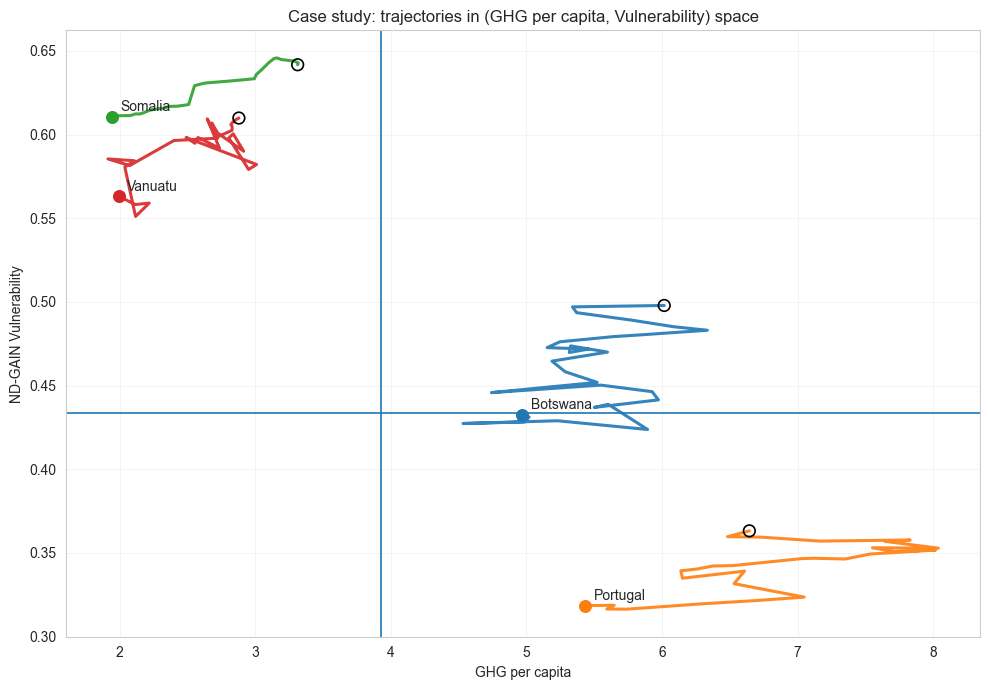

In [11]:
import matplotlib.pyplot as plt

# --- 1) Case-study DF (nutzt deinen bestehenden Helper) ---
case_df = build_case_study_df(merged_df, iso3_case)

# --- 2) Globale Schwellenwerte: Median über ALLE Jahre/Zeilen (inline, kein Helper) ---
base = merged_df[["GHG_per_capita", "Vulnerability"]].dropna()
ghg_cut = float(base["GHG_per_capita"].median())
vuln_cut = float(base["Vulnerability"].median())

# --- 3) Plot ---
fig, ax = plt.subplots(figsize=(10, 7))

# Quadrantenlinien
ax.axvline(ghg_cut, linewidth=1.2)
ax.axhline(vuln_cut, linewidth=1.2)

# Trajektorien + Start/End
for iso, g in case_df.groupby("ISO3", sort=False):
    g = g.sort_values("Year")
    country = g["Country"].iloc[0]

    # Linie (Trajektorie)
    ax.plot(g["GHG_per_capita"], g["Vulnerability"], linewidth=2.2, alpha=0.9)

    # Start/End Punkte (nutzt is_start / is_end aus deinem build_case_study_df)
    gs = g[g["is_start"]].iloc[0]
    ge = g[g["is_end"]].iloc[0]

    # Start: hollow marker
    ax.scatter([gs["GHG_per_capita"]], [gs["Vulnerability"]],
               s=70, facecolors="none", edgecolors="black", linewidths=1.2, zorder=5)

    # End: filled marker
    ax.scatter([ge["GHG_per_capita"]], [ge["Vulnerability"]],
               s=70, zorder=6)

    # Label am Endpunkt
    ax.annotate(country,
                (ge["GHG_per_capita"], ge["Vulnerability"]),
                xytext=(6, 4),
                textcoords="offset points",
                fontsize=10)

ax.set_xlabel("GHG per capita")
ax.set_ylabel("ND-GAIN Vulnerability")
ax.set_title("Case study: trajectories in (GHG per capita, Vulnerability) space")

ax.grid(True, linewidth=0.6, alpha=0.25)
fig.tight_layout()
plt.show()
